<a href="https://colab.research.google.com/github/Gr1lledChee5e/RegressionAnalysis/blob/main/ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAS 640 - Homework 2 - All About ARIMA

## NAME: Riley AC Yee
#Finished Feb 5


## Packages

Use the code cell below to import any packages, modules, or functions needed in this notebook. Keep it concise and avoid importing anything that will not be used.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.deterministic import DeterministicProcess

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR # Vector Autoregression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox_normmax
from statsmodels.stats.diagnostic import acorr_ljungbox

In [ ]:
def arimax_cv(
    y: pd.Series,
    exog: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    p: int=0,
    d: int=0,
    q: int=0,
    P: int=0,
    D: int=0,
    Q: int=0,
    s: int=0,
    trend: str='t'
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]
        X_train = exog.iloc[:train_end]
        X_test  = exog.iloc[train_end:train_end + h]

        # ARIMA Model

        model = ARIMA(y_train, exog=X_train, order=(p, d, q), seasonal_order=(P, D, Q, s), trend=trend).fit()

        # Forecast next h periods
        y_hat = model.forecast(steps = h, exog=X_test)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

In [ ]:
def arima_cv(
    y: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    p: int=0,
    d: int=0,
    q: int=0,
    P: int=0,
    D: int=0,
    Q: int=0,
    s: int=0,
    trend: str='t'
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # ARIMA Model

        model = ARIMA(y_train, order=(p, d, q), seasonal_order=(P, D, Q, s), trend=trend).fit()

        # Forecast next h periods
        y_hat = model.forecast(steps = h)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

In [ ]:
def tslm_cv(
    y: pd.Series,
    h: int,
    initial: int,
    step: int = 1,
    trend_order: int=0,
    seasonal: bool=False,
    period: int=12
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # Build deterministic terms on training index
        dp = DeterministicProcess(
            index=y_train.index,
            constant=True,
            order=trend_order,
            seasonal=seasonal,
            period=period
        )

        X_train = dp.in_sample()
        model = sm.OLS(y_train, X_train).fit()

        # Forecast next h periods
        X_fut = dp.out_of_sample(steps=h)
        y_hat = model.predict(X_fut)
        y_hat = pd.Series(y_hat, index=X_fut.index)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)

        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    #return cv_df, metrics
    return metrics

In [ ]:
def lb_plot(model_fit):
  results = acorr_ljungbox(model_fit.resid)
  lags = results.index + 1
  plt.figure(figsize=(12,6))
  plt.scatter(x=lags, y=results['lb_pvalue'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.ylim(0, 1)
  plt.show()

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf_plot(y, max_p=4, max_q=4):
    y = y.dropna()
    y = np.asarray(y)
    n = len(y)
    crit = 2 / np.sqrt(n)  # approx 95% CI

    table = np.empty((max_p + 1, max_q + 1), dtype=object)

    for p in range(max_p + 1):
        if p == 0:
            resid = y - y.mean()
        else:
            ar = AutoReg(y, lags=p, old_names=False).fit()
            resid = ar.resid

        r = acf(resid, nlags=max_q, fft=False)

        for q in range(max_q + 1):
            table[p, q] = "o" if abs(r[q]) < crit else "x"

    return table

In [ ]:
def acf_plots(y, lags=20, pacf_method="ywm"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y = y.dropna()
    plot_acf(y, lags=lags, ax=axes[0])
    plot_pacf(y, lags=lags,  method=pacf_method, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    axes[0].set_xlim((0, lags))
    axes[1].set_xlim((0, lags))
    plt.tight_layout()
    return fig.show()

In [ ]:
def accuracy(y_observed, y_forecast):
  mae = np.mean(np.abs(y_observed - y_forecast))
  rmse = np.sqrt(np.mean((y_observed - y_forecast)**2))
  mape = np.mean(np.abs((y_observed - y_forecast) / y_observed)) * 100
  print(f'''
    MAE: {mae}
    RMSE: {rmse}
    MAPE: {mape}
  ''')

## Part 1 - ARIMA Model Specification

**Instructions:** For each time series in the `tsData` dataset...
+ Use the ACF, PACF, and EACF functions as needed to determine an appropriate ARIMA model
+ Show all work needed to support your answer.
+ Do not forget to ensure data is stationary first!
+ Final answer should be of the form:
+ “ARIMA(p,d,q)”
+ For y1-y3 ONLY, add a BRIEF explanation why you chose these values (for y4-y10 I'll assume you used similar logic, so need to explain)
+ **NOTE:** You do not need to fit these models, just specify them based on the plots
+ **NOTE:** None of these have seasonal terms, so only p, d, q here

In [ ]:
tsData = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/misc/tsDataHW2.csv')
tsData['date'] = pd.to_datetime(tsData['date'])
tsData = tsData.set_index('date')
tsData.head()

,date,y1,y2,y3,y4,y5,y6,y7,y8,y9,y10
0,2017-01-01,-1.402566,-2.168558,-1.604770,1.604859,-1.200457,1.527660,1.791570,-3.768586,-1.091462,-0.282131
1,2017-02-01,-0.483590,-1.797688,-2.739739,2.026041,0.351022,-0.810520,4.035366,-10.731202,0.667155,0.746383
2,2017-03-01,-1.848150,-1.565277,-1.416238,0.825312,0.736122,-0.223151,5.170016,-20.483891,0.109892,1.954126
3,2017-04-01,-0.242825,-0.206140,-1.643120,0.948329,1.888831,-1.079992,5.196782,-32.051632,-3.371181,1.397208
4,2017-05-01,-0.467829,-0.552697,0.223646,1.472723,0.028698,-0.707644,3.853494,-44.736406,-2.226360,1.177455


### $y_1$

**Final Model:** ARIMA(p, d, q)

**Justification:** (1,0,1)

In [ ]:
def stationarity_tests(series):

    adf = adfuller(series.dropna())
    kpss_test = kpss(series.dropna(), nlags="auto")

    print("ADF p-value:", adf[1])
    print("KPSS p-value:", kpss_test[1])


In [ ]:
def acf_pacf(series, lags=20):

    fig, ax = plt.subplots(1,2, figsize=(12,4))

    plot_acf(series.dropna(), lags=lags, ax=ax[0])
    plot_pacf(series.dropna(), lags=lags, ax=ax[1])

    ax[0].set_title("ACF")
    ax[1].set_title("PACF")

    plt.show()


In [ ]:
y1 = tsData['y1']
stationarity_tests(y1)

ADF p-value: 0.0001406225083086644
KPSS p-value: 0.1


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


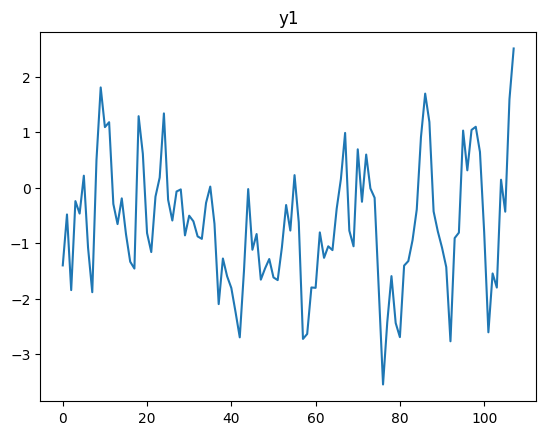

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.0001406225083086644
KPSS p-value: 0.1
ADF p-value: 1.0664455888887026e-07
KPSS p-value: 0.1


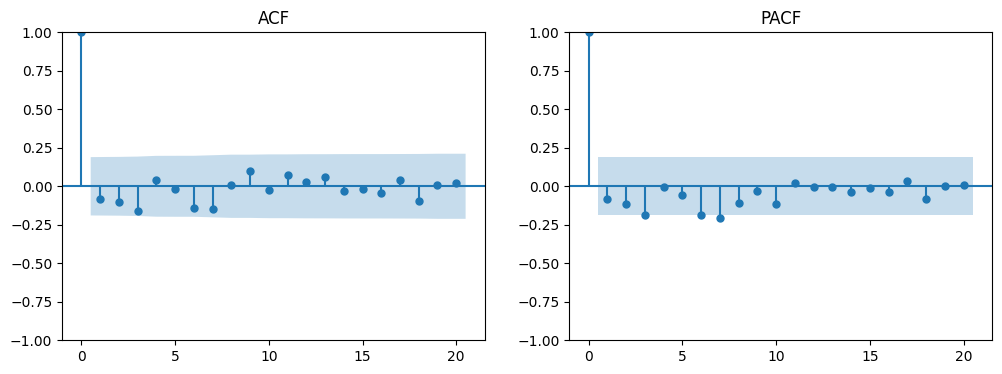

In [ ]:
plt.plot(y1)
plt.title("y1")
plt.show()

stationarity_tests(y1)

y1_diff = y1.diff().dropna()

stationarity_tests(y1_diff)

acf_pacf(y1_diff)

In [ ]:
m_arima = ARIMA(y1, order=(1,0,1), seasonal_order = (0,1,0,10)).fit()
print(m_arima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                y1   No. Observations:                  108
Model:             ARIMA(1, 0, 1)x(0, 1, [], 10)   Log Likelihood                -159.575
Date:                           Mon, 09 Feb 2026   AIC                            325.149
Time:                                   19:45:11   BIC                            332.904
Sample:                                        0   HQIC                           328.286
                                           - 108                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5183      0.189      2.746      0.006       0.148       0.888
ma.L1          0.0765      0.190      0.402

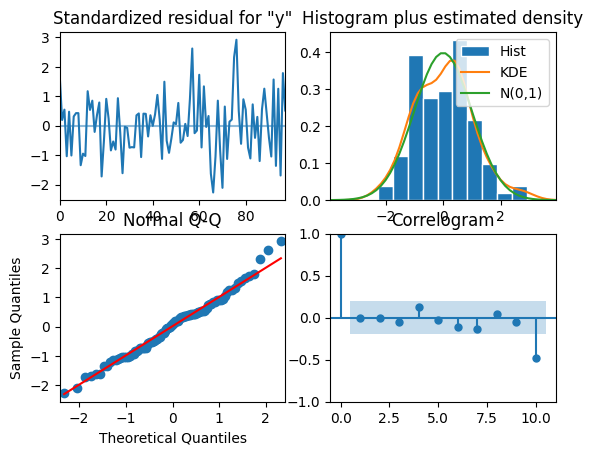

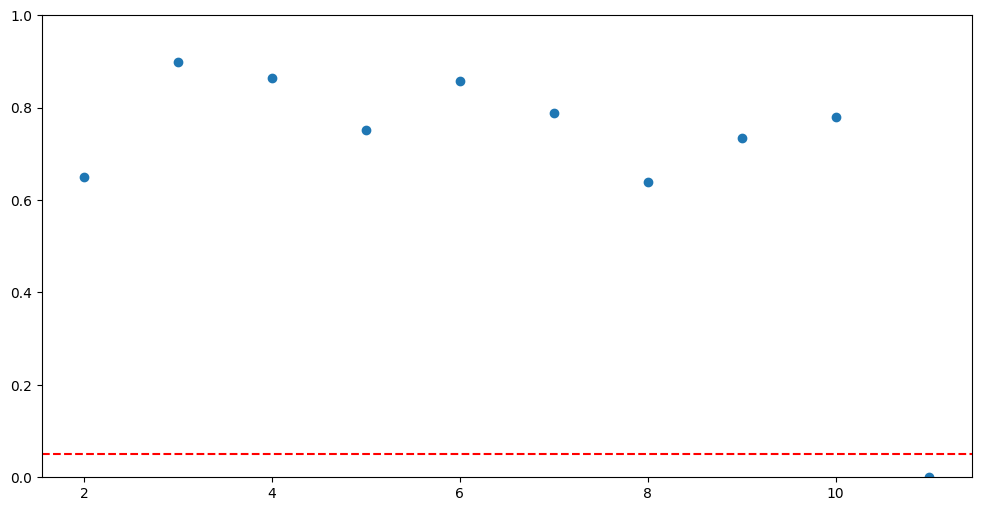

In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

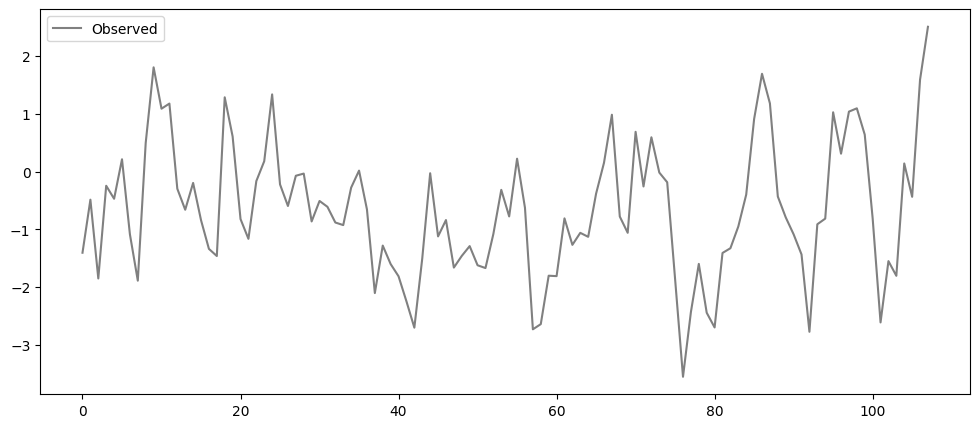

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(y1, color='grey', label='Observed')
plt.legend()
plt.show()

In [ ]:
print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

Arima:  1.2344570467733025


### $y_2$

**Final Model:** ARIMA(p, d, q) (1,1,1)

**Justification:** Your Comments Here

ADF p-value: 0.6932557165847675
KPSS p-value: 0.01


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


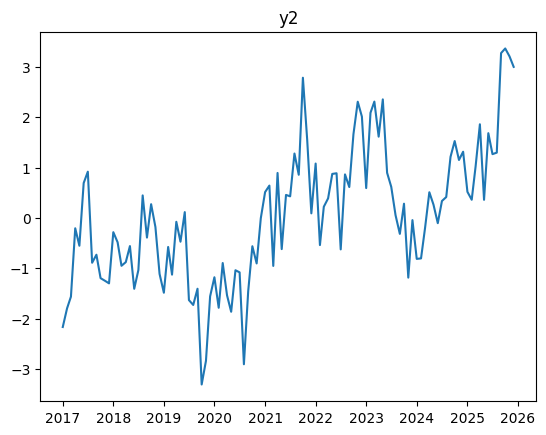

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.6932557165847675
KPSS p-value: 0.01
ADF p-value: 0.0024127220488840096
KPSS p-value: 0.1


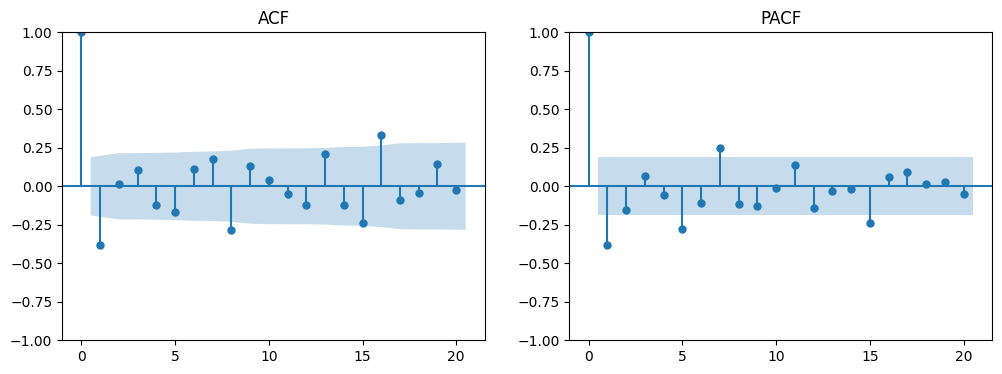

In [ ]:
y2 = tsData['y2']
stationarity_tests(y2)

plt.plot(y2)
plt.title("y2")
plt.show()

stationarity_tests(y2)

y2_diff = y2.diff().dropna()

stationarity_tests(y2_diff)

acf_pacf(y2_diff)




In [ ]:
m_arima = ARIMA(y2, order=(1,1,1), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                               y2   No. Observations:                  108
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 10)   Log Likelihood                -132.485
Date:                          Mon, 09 Feb 2026   AIC                            272.971
Time:                                  20:03:08   BIC                            283.269
Sample:                              01-01-2017   HQIC                           277.135
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0119      0.218      0.054      0.957      -0.416       0.440
ma.L1         -0.4568      0.209     -2.182      0.

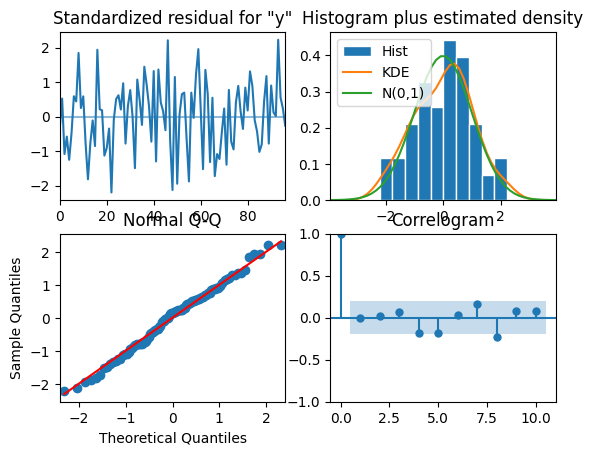

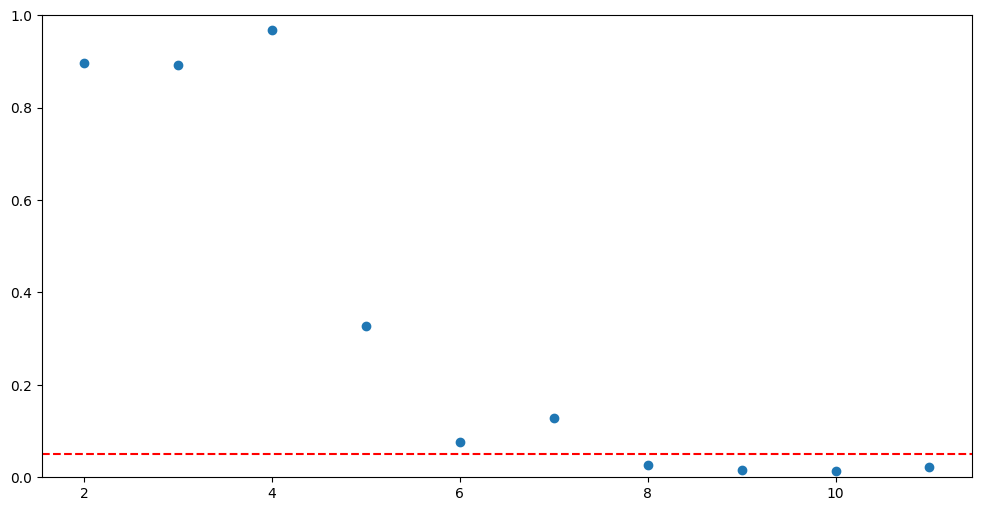

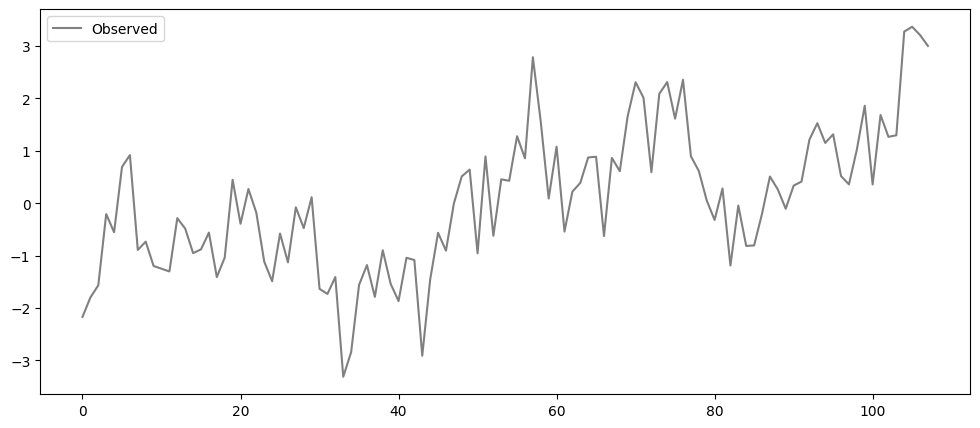

Arima:  0.964911890802082


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(y2, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_3$

**Final Model:** ARIMA(p, d, q)

**Justification:** (2,0,0)

ADF p-value: 0.026644110245387865
KPSS p-value: 0.0777522165561142


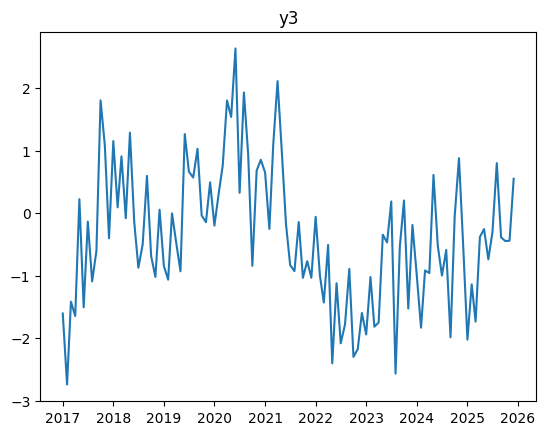

ADF p-value: 0.026644110245387865
KPSS p-value: 0.0777522165561142
ADF p-value: 4.347646033403901e-12
KPSS p-value: 0.1


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


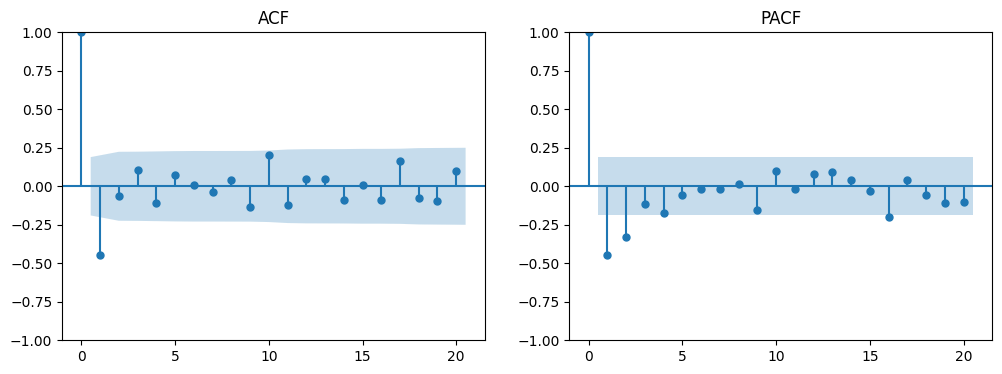

In [ ]:
y3 = tsData['y3']
stationarity_tests(y3)

plt.plot(y3)
plt.title("y3")
plt.show()

stationarity_tests(y3)

y3_diff = y3.diff().dropna()

stationarity_tests(y3_diff)

acf_pacf(y3_diff)

In [ ]:
m_arima = ARIMA(y3, order=(2,0,0), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 y3   No. Observations:                  108
Model:             ARIMA(2, 0, 0)x(0, 1, [1], 10)   Log Likelihood                -140.045
Date:                            Mon, 09 Feb 2026   AIC                            288.090
Time:                                    20:03:49   BIC                            298.430
Sample:                                01-01-2017   HQIC                           292.272
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4201      0.112      3.761      0.000       0.201       0.639
ar.L2          0.2581      0.095   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


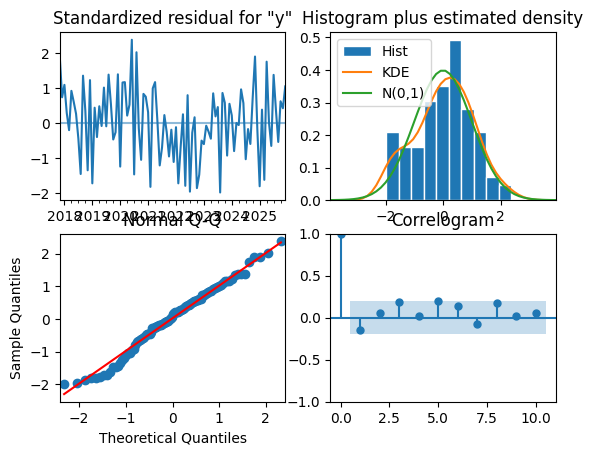

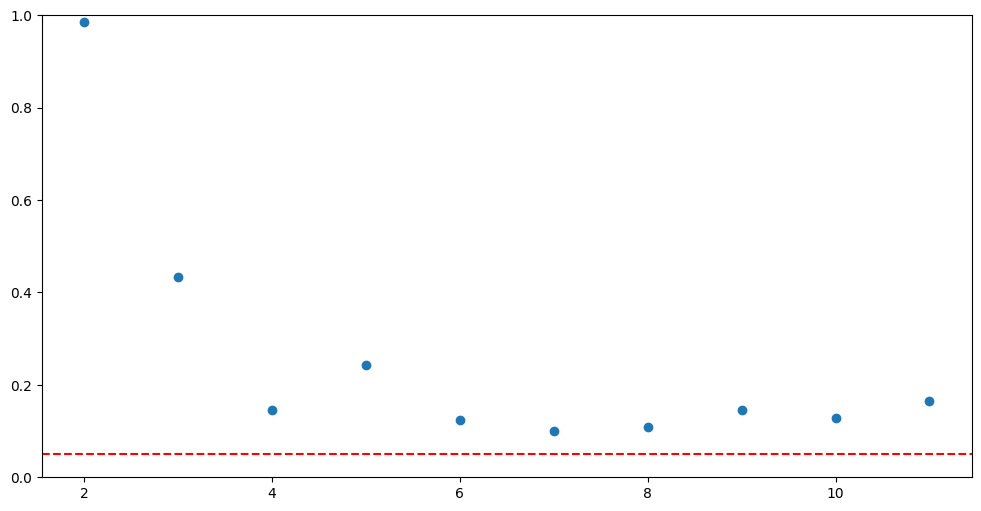

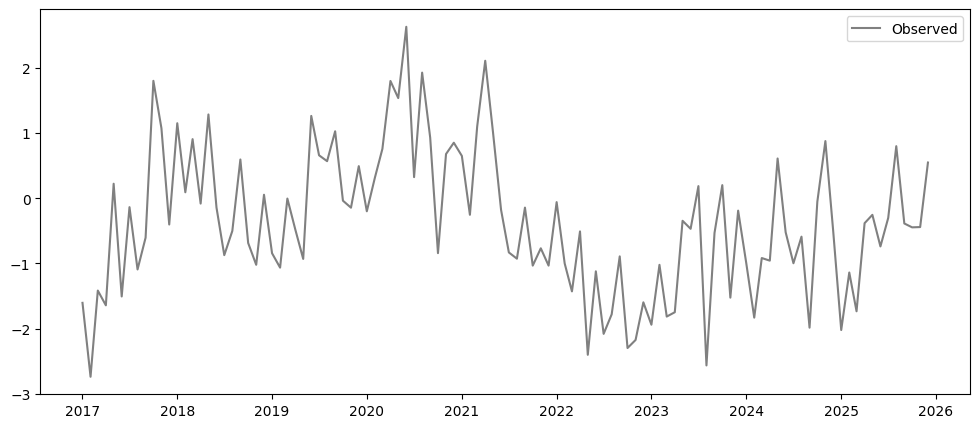

Arima:  1.0985948051450136


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(y3, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_4$

**Final Model:** ARIMA(p, d, q)
(0,1,0)

ADF p-value: 0.09659012322413918
KPSS p-value: 0.04047318527301464


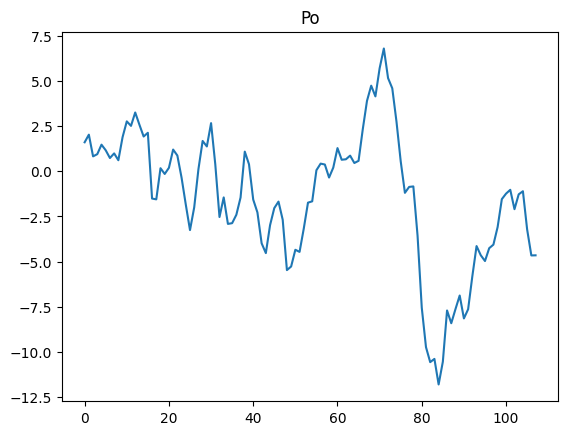

ADF p-value: 0.09659012322413918
KPSS p-value: 0.04047318527301464
ADF p-value: 7.10624376871473e-07
KPSS p-value: 0.1


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


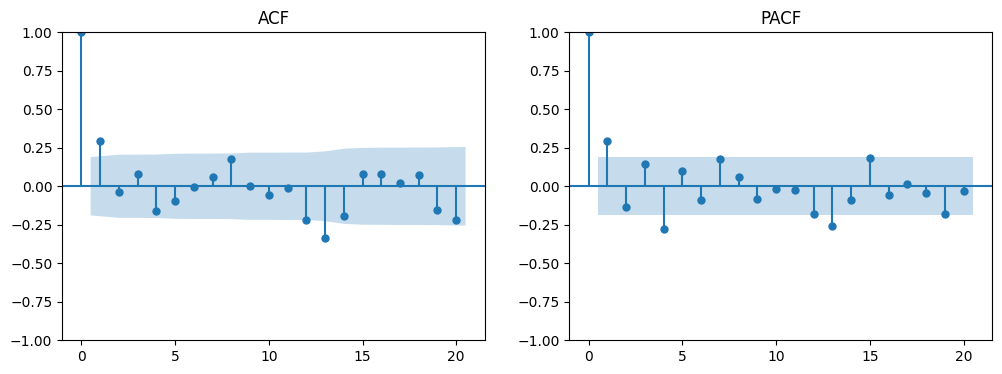

In [ ]:

Po = tsData['y4']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(0,1,0), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                y10   No. Observations:                  108
Model:             ARIMA(0, 1, 0)x(0, 1, [1], 10)   Log Likelihood                -160.564
Date:                            Mon, 09 Feb 2026   AIC                            325.128
Time:                                    20:05:17   BIC                            330.278
Sample:                                         0   HQIC                           327.211
                                            - 108                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.S.L10      -0.9941      4.231     -0.235      0.814      -9.286       7.298
sigma2         1.2637      5.270   

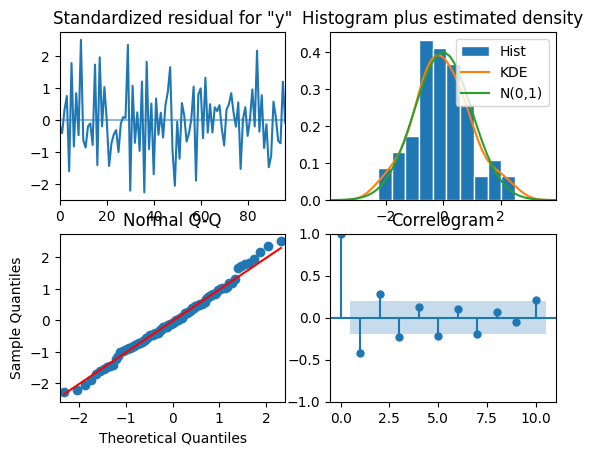

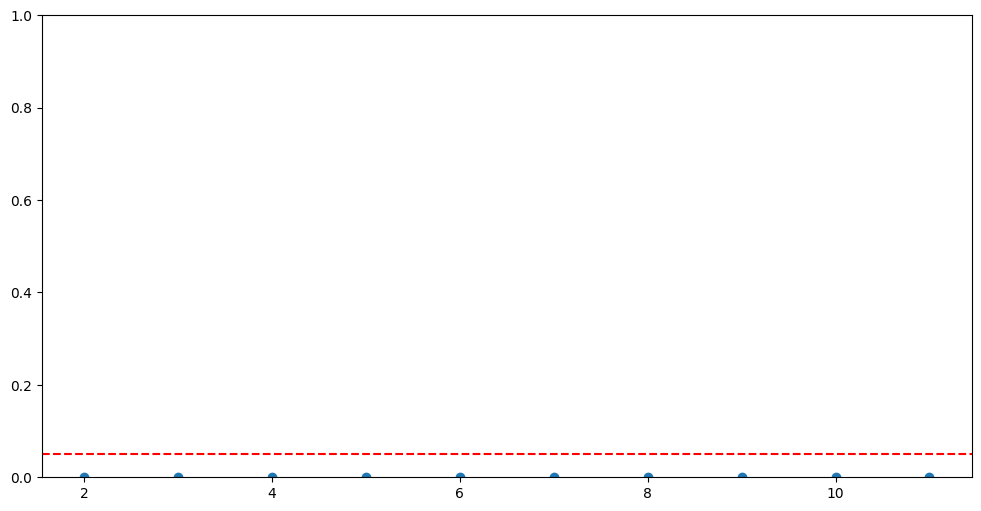

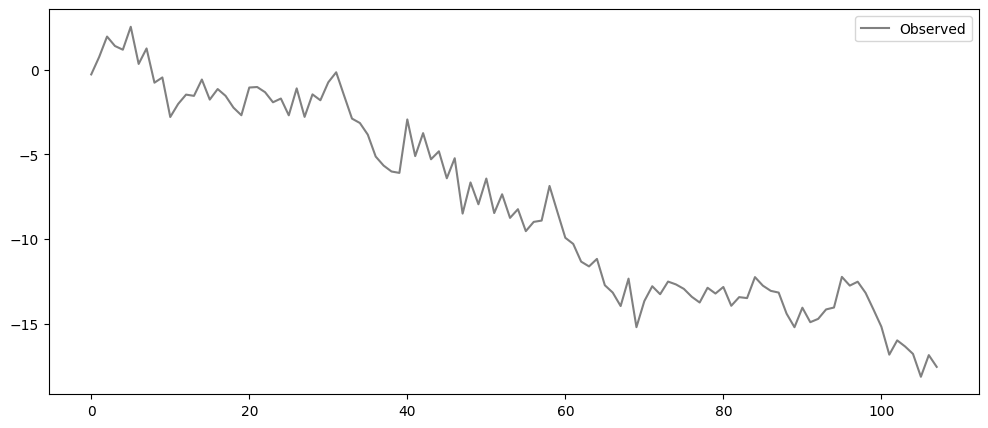

Arima:  1.3082161149926148


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_5$

**Final Model:** ARIMA(p, d, q)
(1,1,1)

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.11290799801499246
KPSS p-value: 0.1


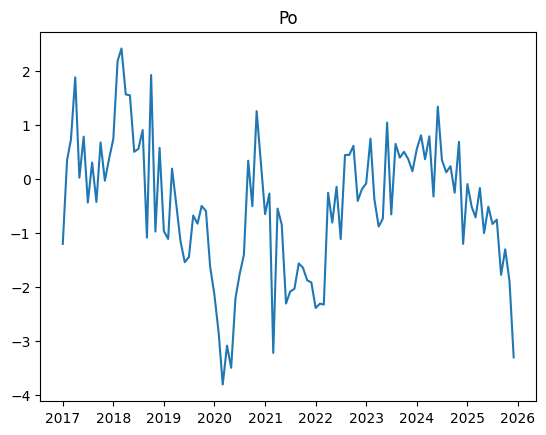

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.11290799801499246
KPSS p-value: 0.1
ADF p-value: 2.814800538731926e-05
KPSS p-value: 0.1


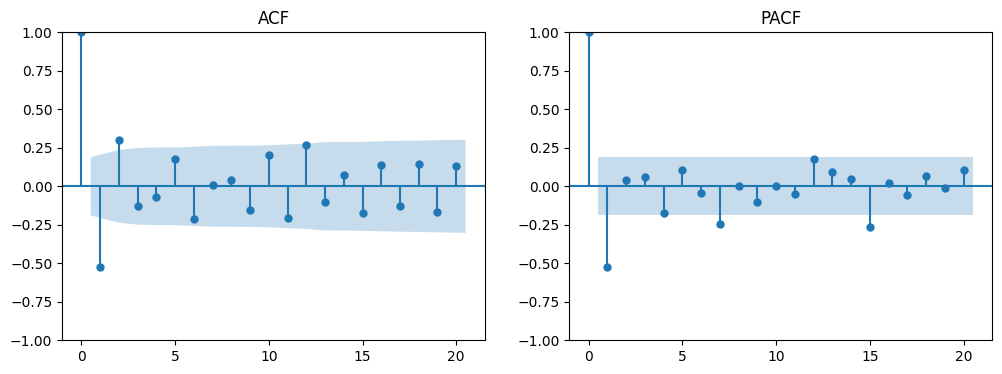

In [ ]:

Po = tsData['y5']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(1,1,1), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                               y5   No. Observations:                  108
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 10)   Log Likelihood                -131.390
Date:                          Mon, 09 Feb 2026   AIC                            270.779
Time:                                  20:06:18   BIC                            281.078
Sample:                              01-01-2017   HQIC                           274.943
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4397      0.196     -2.247      0.025      -0.823      -0.056
ma.L1         -0.0242      0.242     -0.100      0.

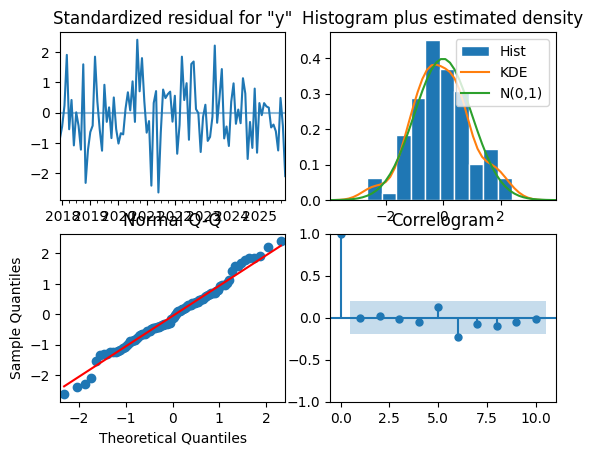

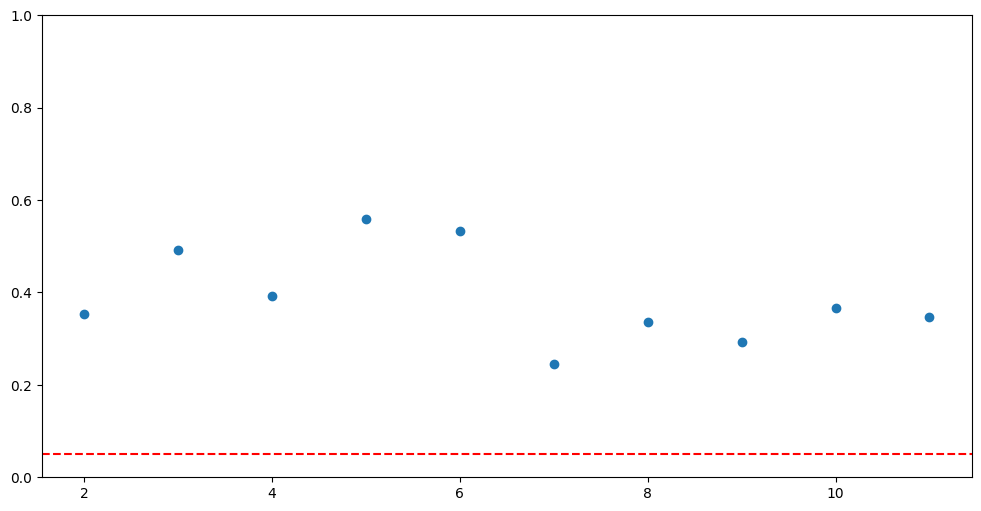

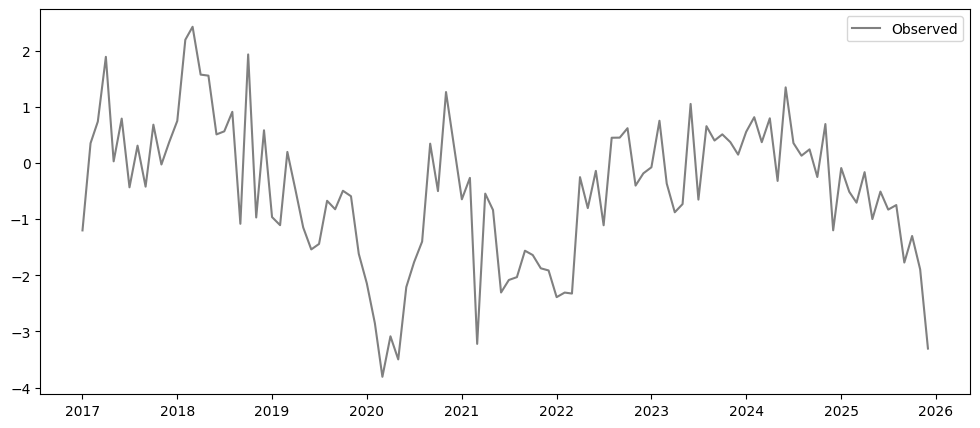

Arima:  0.9633024183607576


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_6$

**Final Model:** ARIMA(p, d, q)
(1,1,1)

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.07734063824246244
KPSS p-value: 0.1


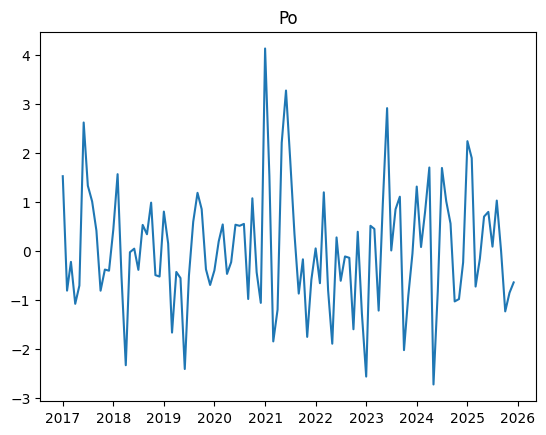

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.07734063824246244
KPSS p-value: 0.1
ADF p-value: 9.304848555991916e-06
KPSS p-value: 0.1


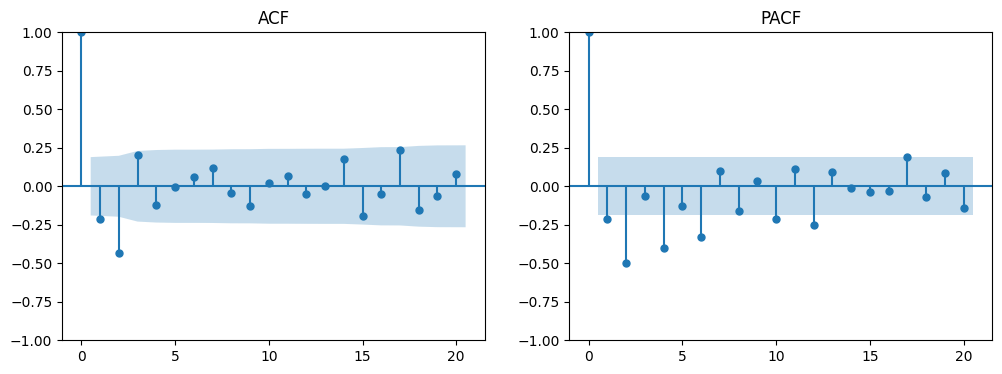

In [ ]:

Po = tsData['y6']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(1,1,1), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                               y6   No. Observations:                  108
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 10)   Log Likelihood                -173.178
Date:                          Mon, 09 Feb 2026   AIC                            354.356
Time:                                  20:06:32   BIC                            364.655
Sample:                              01-01-2017   HQIC                           358.521
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2121      0.134      1.584      0.113      -0.050       0.474
ma.L1         -0.9996      8.634     -0.116      0.

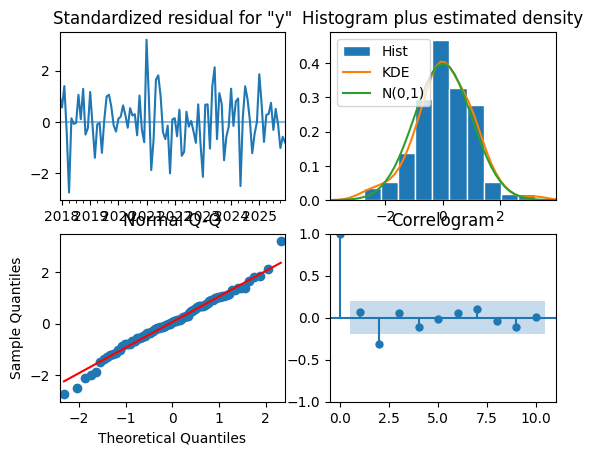

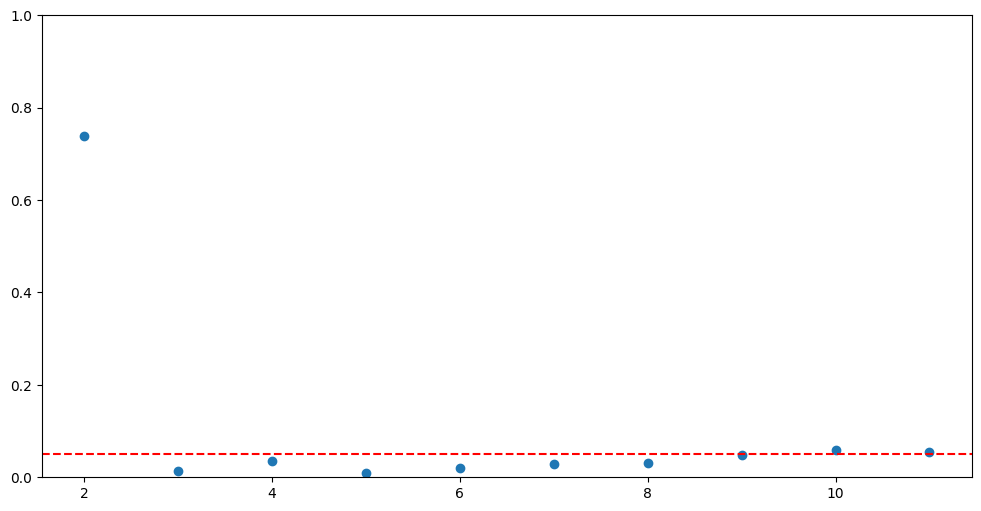

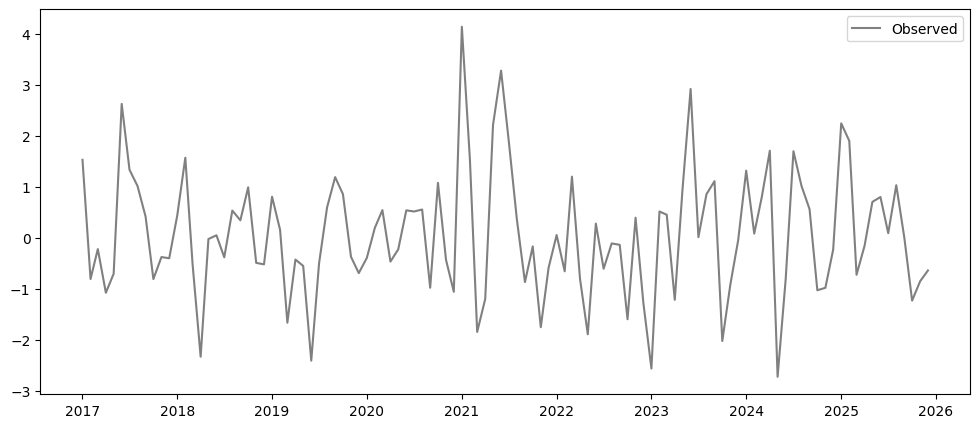

Arima:  1.4711358854770429


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_7$

**Final Model:** ARIMA(p, d, q)
(1,1,0)

ADF p-value: 0.8962796951947039
KPSS p-value: 0.01


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


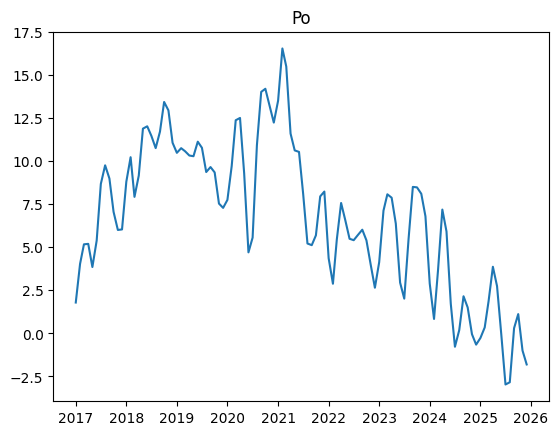

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.8962796951947039
KPSS p-value: 0.01
ADF p-value: 0.003146284135481339
KPSS p-value: 0.1


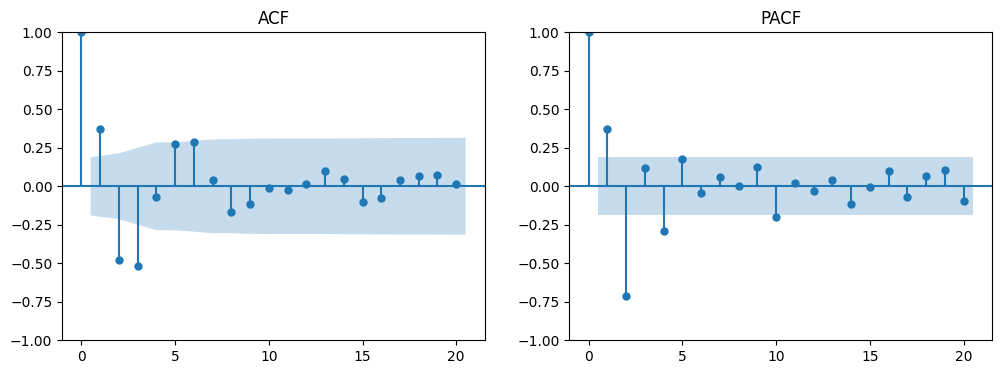

In [ ]:

Po = tsData['y7']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(1,1,0), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                                 y7   No. Observations:                  108
Model:             ARIMA(1, 1, 0)x(0, 1, [1], 10)   Log Likelihood                -204.137
Date:                            Mon, 09 Feb 2026   AIC                            414.275
Time:                                    20:07:42   BIC                            421.999
Sample:                                01-01-2017   HQIC                           417.398
                                     - 12-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3981      0.097      4.115      0.000       0.208       0.588
ma.S.L10      -0.9986     18.882   

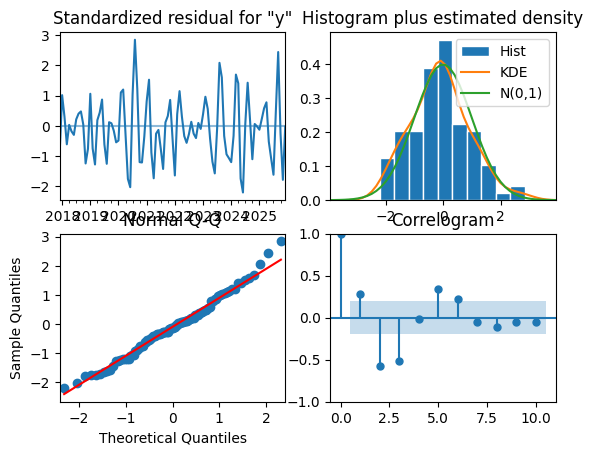

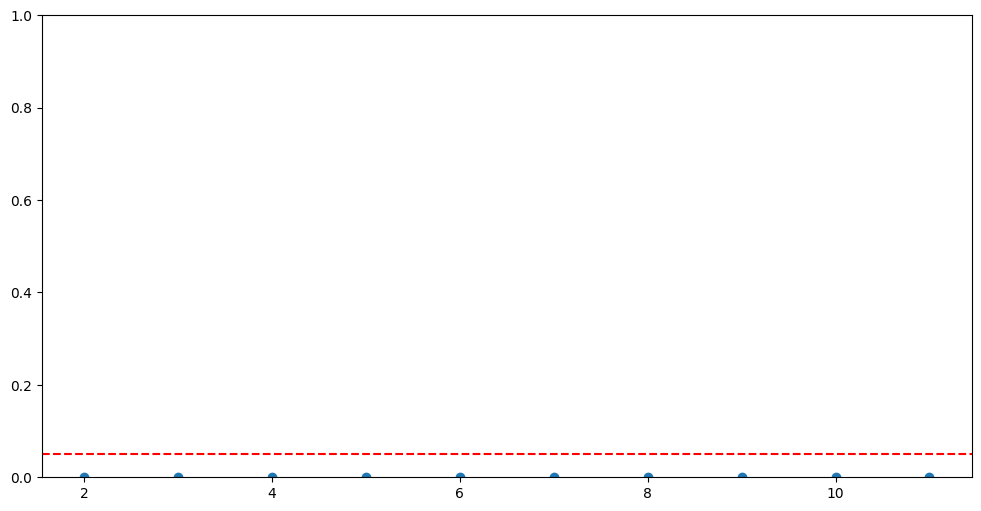

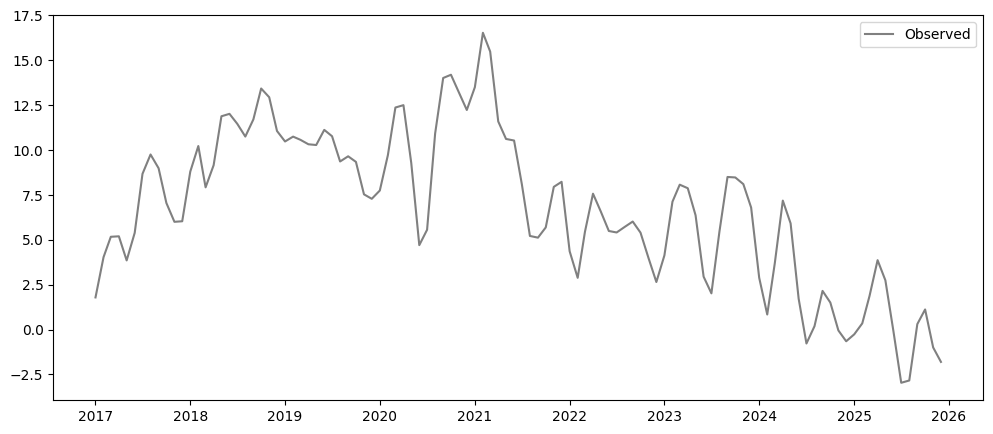

Arima:  1.9274882099779123


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_8$

**Final Model:** ARIMA(p, d, q)
(0,1,1)

ADF p-value: 1.0
KPSS p-value: 0.01


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


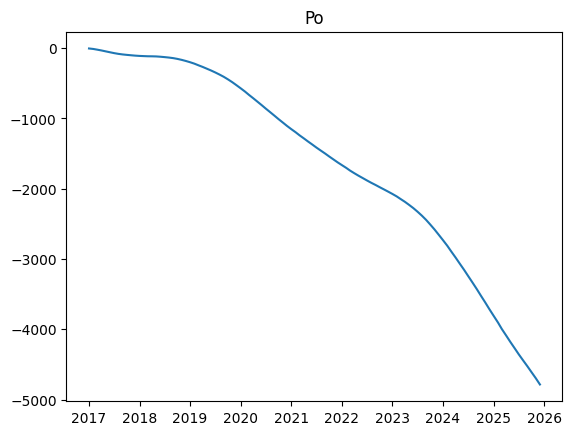

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 1.0
KPSS p-value: 0.01
ADF p-value: 0.8954428732454
KPSS p-value: 0.01


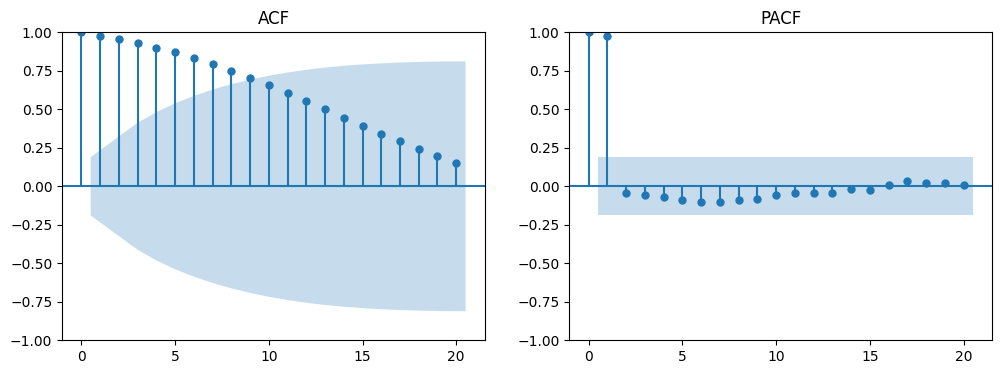

In [ ]:

Po = tsData['y8']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(0,1,1), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as 

                                    SARIMAX Results                                     
Dep. Variable:                               y8   No. Observations:                  108
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 10)   Log Likelihood                -336.653
Date:                          Mon, 09 Feb 2026   AIC                            679.305
Time:                                  20:08:21   BIC                            687.029
Sample:                              01-01-2017   HQIC                           682.429
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.9980      1.293      0.772      0.440      -1.537       3.533
ma.S.L10       0.5774      0.116      4.974      0.

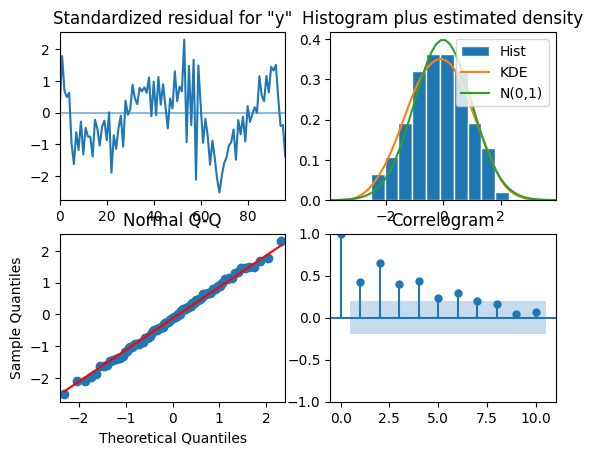

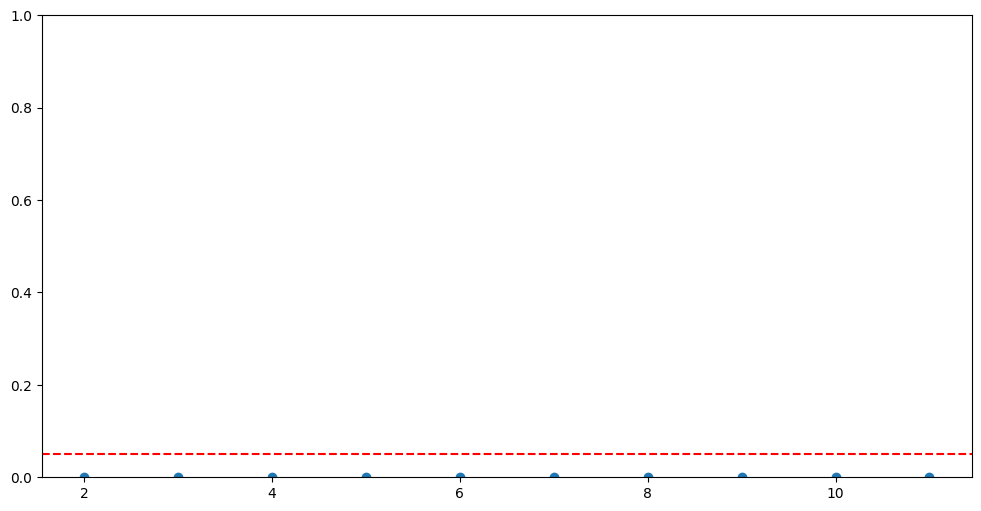

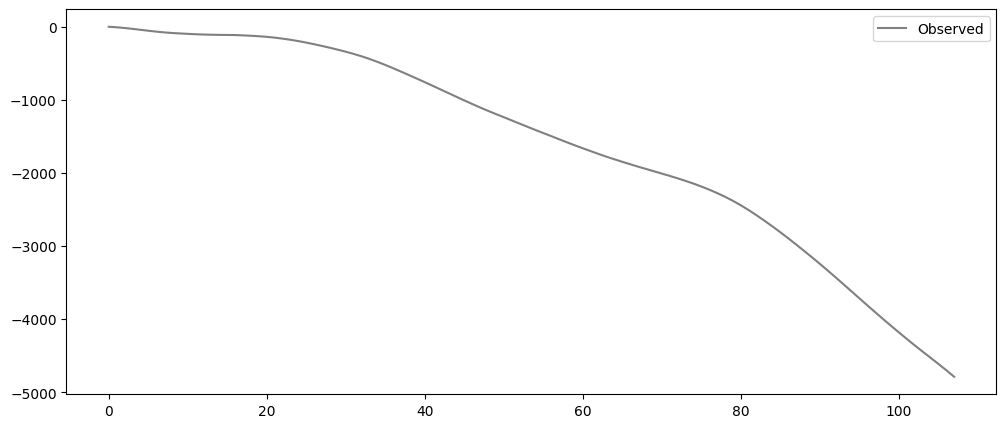

Arima:  3.3545959476940244


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_9$

**Final Model:** ARIMA(p, d, q)
(1,1,1)

ADF p-value: 0.6971070306234327
KPSS p-value: 0.016428502970338134


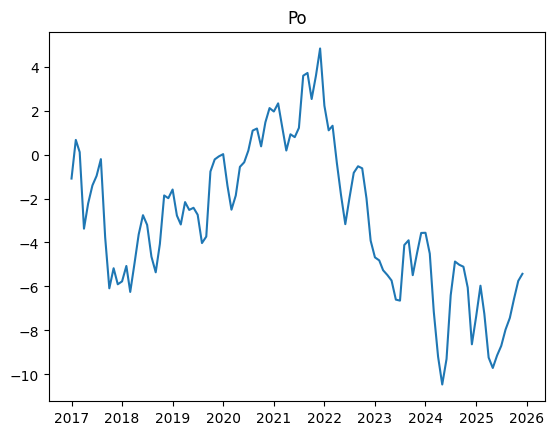

ADF p-value: 0.6971070306234327
KPSS p-value: 0.016428502970338134
ADF p-value: 1.49163099717227e-11
KPSS p-value: 0.1


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


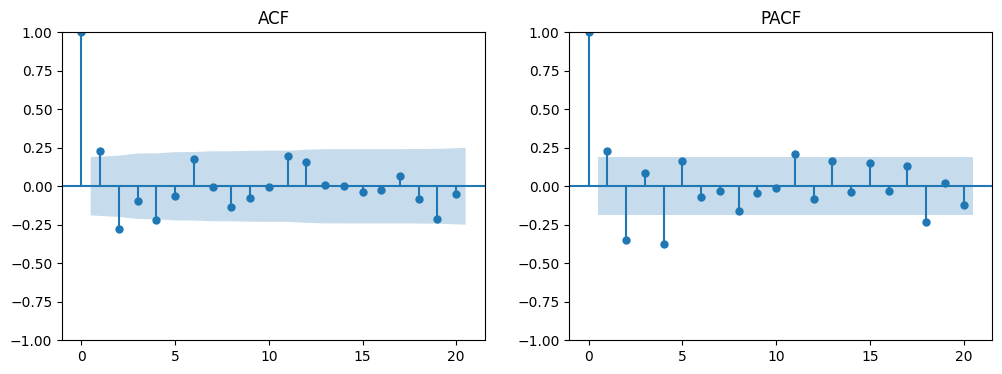

In [ ]:

Po = tsData['y9']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(1,1,1), seasonal_order = (1,1,1,10)).fit()
print(m_arima.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                    SARIMAX Results                                     
Dep. Variable:                               y9   No. Observations:                  108
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 10)   Log Likelihood                -157.325
Date:                          Mon, 09 Feb 2026   AIC                            324.649
Time:                                  20:09:32   BIC                            337.523
Sample:                              01-01-2017   HQIC                           329.855
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3095      0.113     -2.738      0.006      -0.531      -0.088
ma.L1          0.9981      1.539      0.648      0.

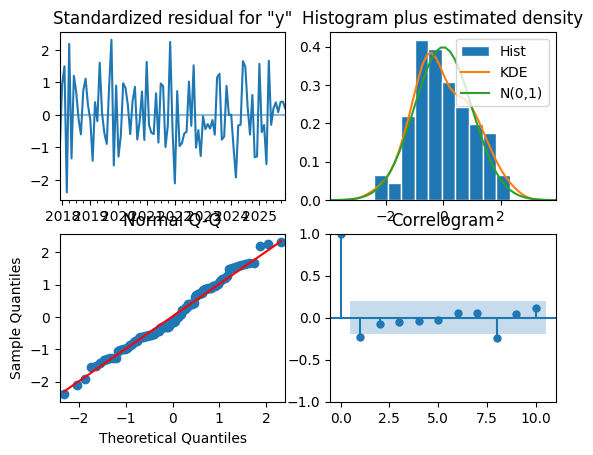

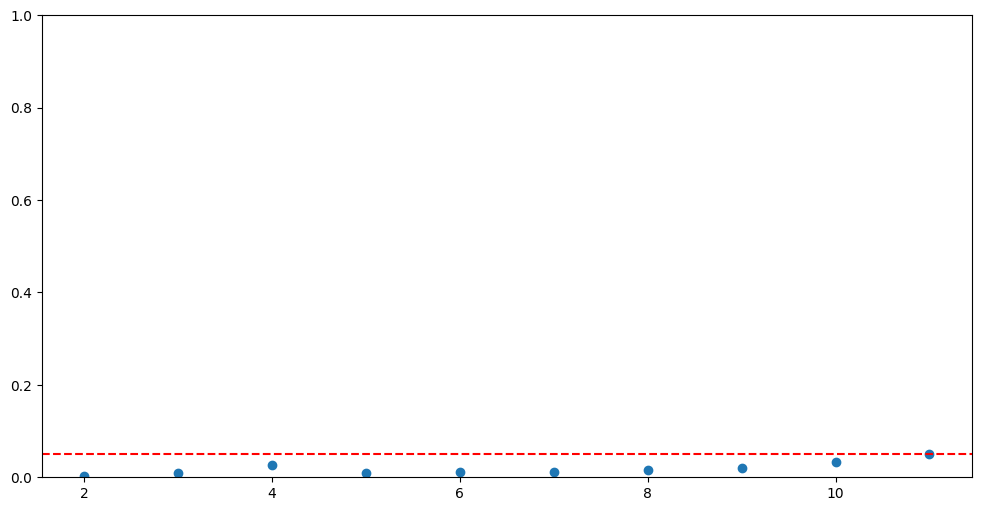

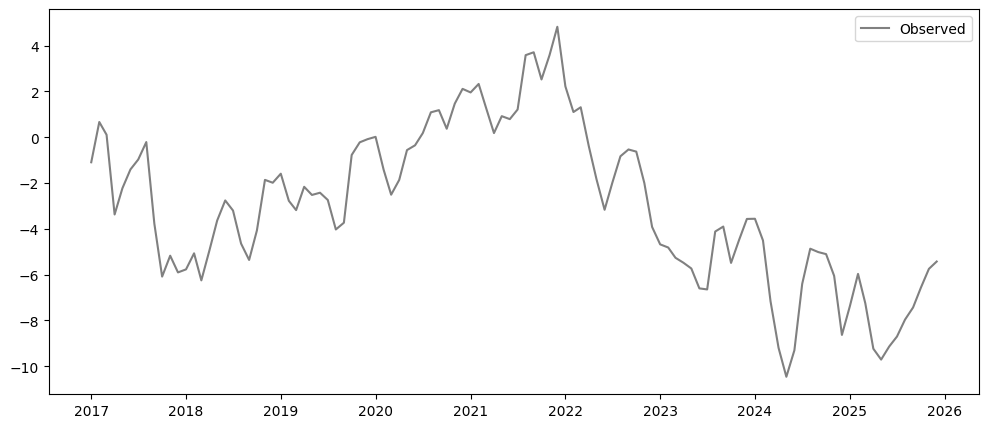

Arima:  1.4405412364362338


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

### $y_{10}$

**Final Model:** ARIMA(p, d, q)
(0,0,1)

ADF p-value: 0.7963033903307889
KPSS p-value: 0.01


/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


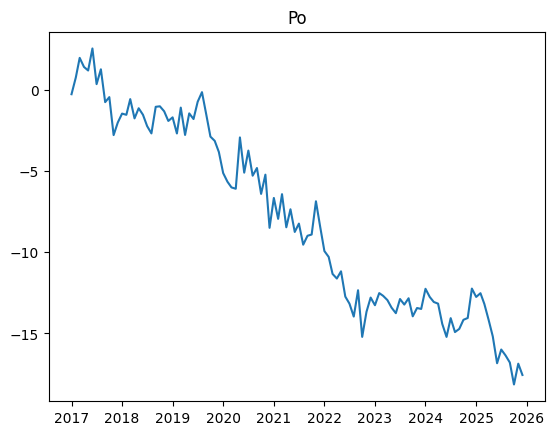

/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")
/tmp/ipython-input-2508008552.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(series.dropna(), nlags="auto")


ADF p-value: 0.7963033903307889
KPSS p-value: 0.01
ADF p-value: 3.4560422084077286e-11
KPSS p-value: 0.1


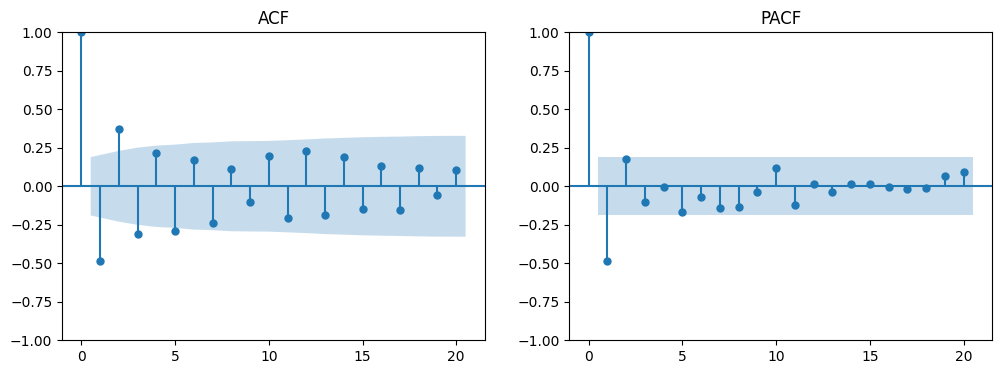

In [ ]:

Po = tsData['y10']
stationarity_tests(Po)

plt.plot(Po)
plt.title("Po")
plt.show()

stationarity_tests(Po)

Po_diff = Po.diff().dropna()

stationarity_tests(Po_diff)

acf_pacf(Po_diff)

In [ ]:
m_arima = ARIMA(Po, order=(0,0,1), seasonal_order = (0,1,1,10)).fit()
print(m_arima.summary())

                                    SARIMAX Results                                     
Dep. Variable:                              y10   No. Observations:                  108
Model:             ARIMA(0, 0, 1)x(0, 1, 1, 10)   Log Likelihood                -204.635
Date:                          Mon, 09 Feb 2026   AIC                            415.270
Time:                                  20:09:54   BIC                            423.025
Sample:                              01-01-2017   HQIC                           418.407
                                   - 12-01-2025                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.5226      0.099      5.299      0.000       0.329       0.716
ma.S.L10       0.0967      0.121      0.801      0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


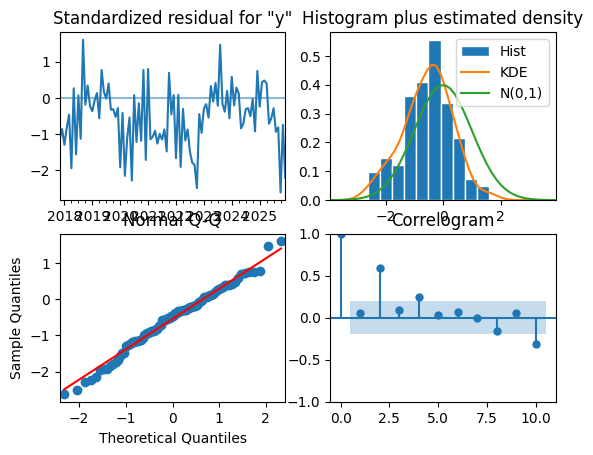

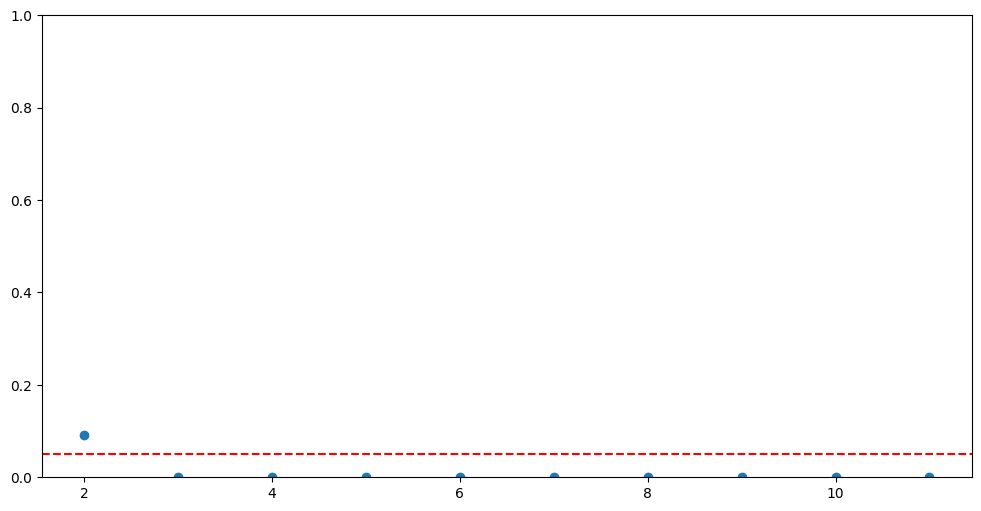

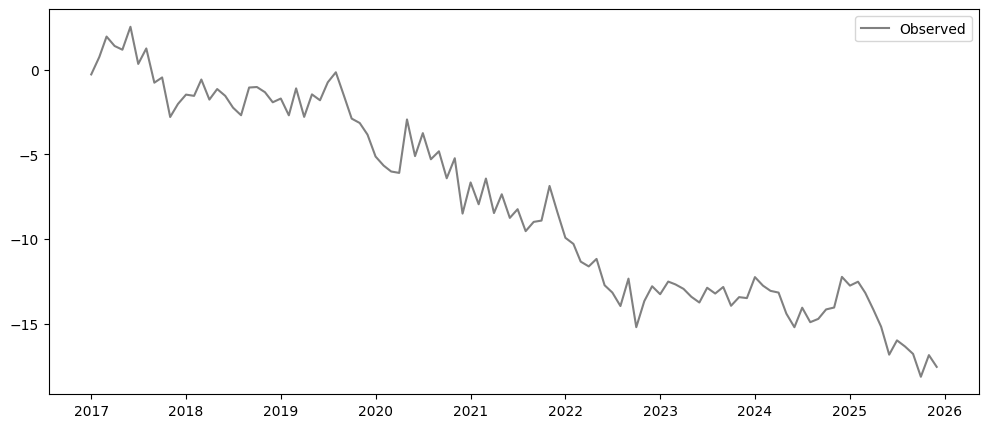

Arima:  1.9023731737332292


In [ ]:
m_arima.plot_diagnostics()
plt.show()
lb_plot(m_arima)

plt.figure(figsize=(12, 5))
plt.plot(Po, color='grey', label='Observed')
plt.legend()
plt.show()

print('Arima: ', np.sqrt(np.mean(m_arima.resid**2)))

## Part 2 - ARIMA Modeling

### 2a - Model Specification

The `construction` dataset represents monthly total construction spending in the US. This is the same dataset that you used in Homework 1.

As in Part 1, please determine an appropriate ARIMA model for this series. Show your work and justify your answer.


**Final Model:**

**Justification:**

In [ ]:
construction = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/misc/TTLCON.csv')
construction.tail()

,observation_date,TTLCON
387,2025-04-01,178179
388,2025-05-01,187454
389,2025-06-01,195762
390,2025-07-01,198093
391,2025-08-01,200576


In [ ]:
# NOTE: When fitting your ARIMA() model, if the mean of your differenced series is non-zero, include trend='t'
#   ARIMA(y, order=(...), trend='t')
#   Try comparing with/without trend='t' included and see the forecast flatline without it.
#   trend='t' is including an intercept in the ARIMA model that you fit to the differenced data, which allows the series to trend up when the difference is reversed



### 2b - Cross Validation

Cross validate the model you found in Part 2a and report the RMSE

+ Compare with the RMSE you found for this series in Homework 1. Make sure you are forecasting the same number of periods in the cross validation for a fair comparison (same "h" value in the function I provided you).
  + **RMSE for ARIMA model in Part 2a:**
  + **RMSE from TSLM model in Homework 1:**

In [ ]:
# Select your series (example: y1)
y = tsData["y1"].asfreq("MS")

# Your chosen ARIMA order from Part 2a
p, d, q = 1, 0, 1


In [ ]:
arima_results = arima_cv(
    y,
    h=12,          # same horizon as HW1
    initial=36,    # starting window (adjust if needed)
    step=1,
    p=p,
    d=d,
    q=q
)

print("ARIMA CV Results:")
print(arima_results)

{'MAE': ..., 'RMSE': ..., 'MAPE%': ...}

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA CV Results:
{'MAE': 1.0466944217624123, 'RMSE': 1.3152420010308714, 'MAPE%': 354.10256596802134}


{'MAE': Ellipsis, 'RMSE': Ellipsis, 'MAPE%': Ellipsis}

In [ ]:
tslm_results = tslm_cv(
    y,
    h=12,
    initial=36,
    step=1,
    trend_order=1,
    seasonal=True,
    period=12
)

print("TSLM CV Results:")
print(tslm_results)

TSLM CV Results:
{'MAE': 1.1460838920265326, 'RMSE': 1.3824513991792178, 'MAPE%': 395.79909338957185}


In [ ]:
print(f"RMSE for ARIMA model in Part 2a:  {arima_results['RMSE']:.2f}")
print(f"RMSE from TSLM model in Homework 1:  {tslm_results['RMSE']:.2f}")

comparison = "better" if arima_results['RMSE'] < tslm_results['RMSE'] else "worse"
print(f"\nThe ARIMA model ({comparison}) than the TSLM model\nbased on cross-validated RMSE.")

RMSE for ARIMA model in Part 2a:  1.32
RMSE from TSLM model in Homework 1:  1.38

The ARIMA model (better) than the TSLM model
based on cross-validated RMSE.


### 2c - Forecasting

Using your model from Part 2a, please forecast through August 2026 (1 year following the end of the data).

Plot the original series with your forecast included.

In [ ]:
final_model = ARIMA(
    y,
    order=(p,d,q)
).fit()

print(final_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     y1   No. Observations:                  108
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -142.282
Date:                Mon, 09 Feb 2026   AIC                            292.563
Time:                        19:49:51   BIC                            303.292
Sample:                    01-01-2017   HQIC                           296.913
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6446      0.224     -2.881      0.004      -1.083      -0.206
ar.L1          0.5334      0.162      3.296      0.001       0.216       0.851
ma.L1          0.1566      0.171      0.914      0.3

In [ ]:
forecast_steps = 12

y_forecast = final_model.forecast(steps=forecast_steps)


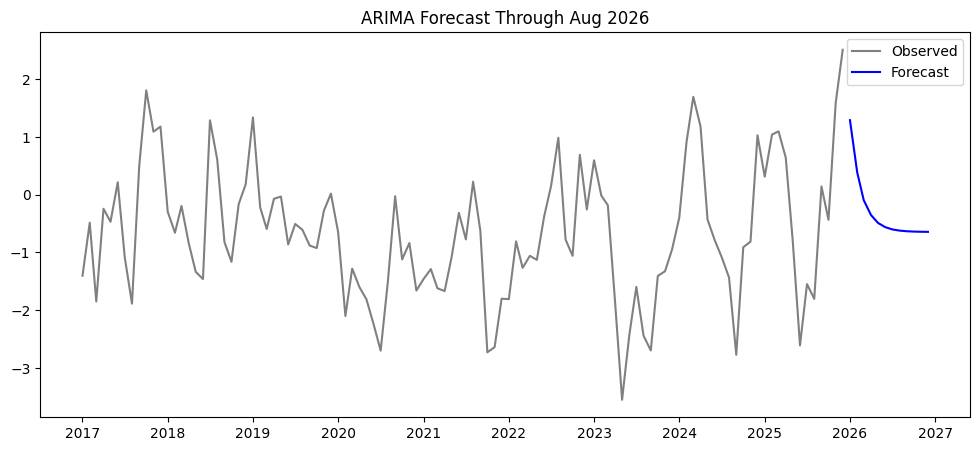

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y, label="Observed", color="gray")
plt.plot(y_forecast, label="Forecast", color="blue")

plt.title("ARIMA Forecast Through Aug 2026")
plt.legend()
plt.show()


### 2d - Residual Diagnostics

Please discuss the validity of your model by performing the residual diagnostics we discussed in class.

**COMMENTS:** *Your Comments Here*

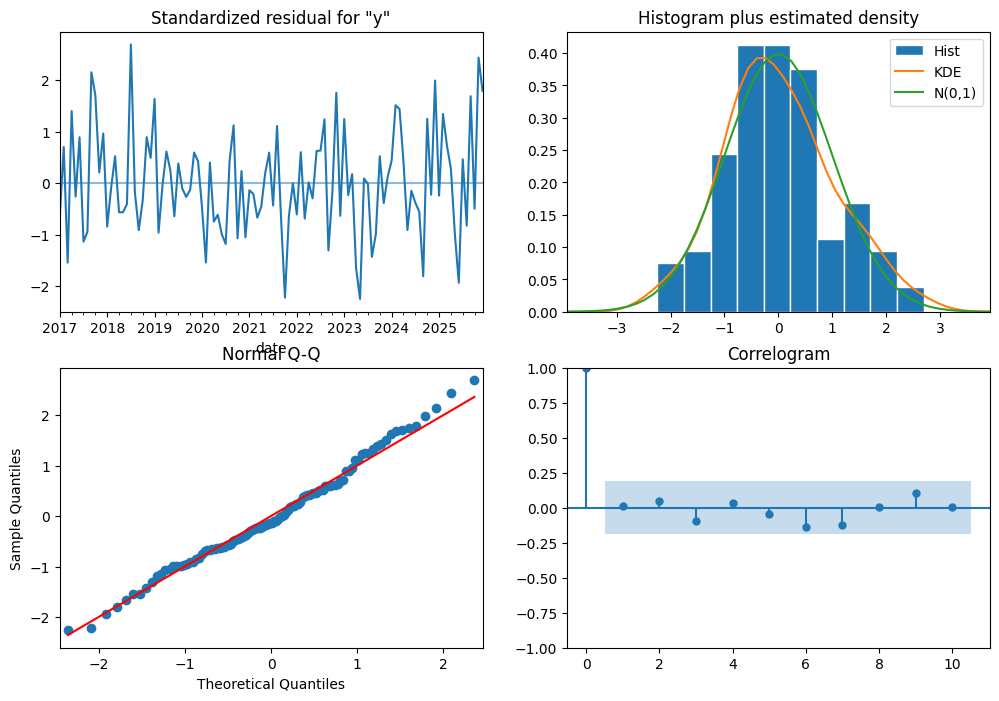

In [ ]:
final_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [ ]:
lb_test = acorr_ljungbox(final_model.resid)

print(lb_test)


     lb_stat  lb_pvalue
1   0.010548   0.918199
2   0.320813   0.851797
3   1.334172   0.721035
4   1.445530   0.836244
5   1.711961   0.887389
6   3.891429   0.691366
7   5.565153   0.591337
8   5.565232   0.695803
9   6.772289   0.660814
10  6.777713   0.746250


In [ ]:
# Some residual autocorrelation remains at low lags, suggesting
# the model may be slightly under-specified.